In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('darkgrid')

In [18]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"
df = pd.read_csv('/content/Datasets/Mall Dataset/Mall_Customers.csv')

fatal: destination path 'Datasets' already exists and is not an empty directory.


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
df.drop('CustomerID',axis=1,inplace=True)

In [20]:
gender_spending_stats = df.groupby('Gender')['Spending Score (1-100)'].describe()
print(gender_spending_stats)

        count       mean       std  min   25%   50%   75%   max
Gender                                                         
Female  112.0  51.526786  24.11495  5.0  35.0  50.0  73.0  99.0
Male     88.0  48.511364  27.89677  1.0  24.5  50.0  70.0  97.0


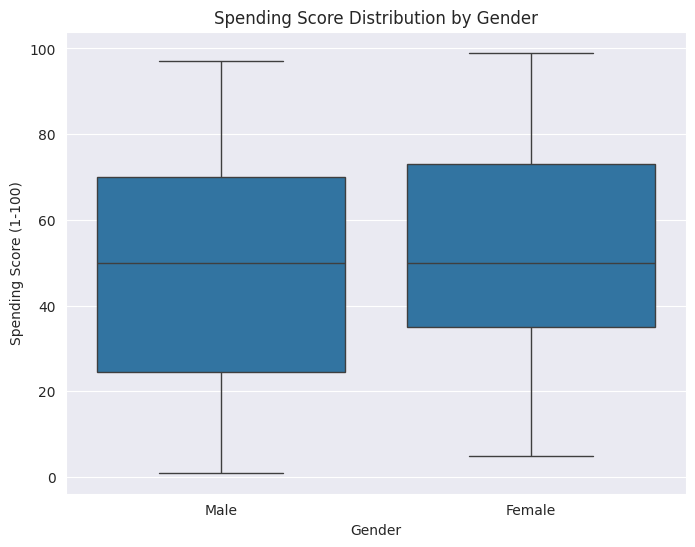

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Spending Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [22]:
df['Spending_to_Income_Ratio'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']
# Handle potential division by zero if Annual Income (k$) could be 0
df['Spending_to_Income_Ratio'] = df['Spending_to_Income_Ratio'].replace([np.inf, -np.inf], np.nan)
df['Spending_to_Income_Ratio'].fillna(0, inplace=True) # Fill NaN values with 0, assuming 0 income means 0 ratio

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spending_to_Income_Ratio']
X = df[features]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("Engineered 'Spending_to_Income_Ratio' and created scaled features (X_scaled).")

Engineered 'Spending_to_Income_Ratio' and created scaled features (X_scaled).


/tmp/ipython-input-372/1828209058.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Spending_to_Income_Ratio'].fillna(0, inplace=True) # Fill NaN values with 0, assuming 0 income means 0 ratio


In [23]:
df['Spending_to_Income_Ratio'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']
# Handle potential division by zero if Annual Income (k$) could be 0
df['Spending_to_Income_Ratio'] = df['Spending_to_Income_Ratio'].replace([np.inf, -np.inf], np.nan)
df['Spending_to_Income_Ratio'] = df['Spending_to_Income_Ratio'].fillna(0) # Fill NaN values with 0, assuming 0 income means 0 ratio

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Spending_to_Income_Ratio']
X = df[features]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("Engineered 'Spending_to_Income_Ratio' and created scaled features (X_scaled).")

Engineered 'Spending_to_Income_Ratio' and created scaled features (X_scaled).


In [30]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values calculated for k from 1 to 10.")

WCSS values calculated for k from 1 to 10.


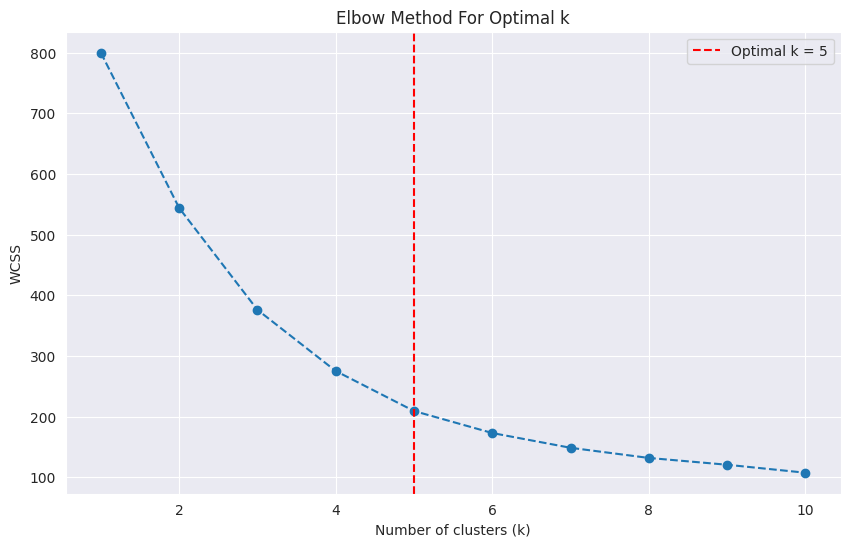

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.legend()
plt.show()

In [26]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_
cluster_centers_scaled = kmeans.cluster_centers_

print(f"K-Means clustering performed with {optimal_k} clusters.")
print("First 5 rows of df with new 'Cluster' column:")
print(df.head())
print("Scaled Cluster Centers:")
print(cluster_centers_scaled)

K-Means clustering performed with 5 clusters.
First 5 rows of df with new 'Cluster' column:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0    Male   19                  15                      39   
1    Male   21                  15                      81   
2  Female   20                  16                       6   
3  Female   23                  16                      77   
4  Female   31                  17                      40   

   Spending_to_Income_Ratio  Cluster  
0                  2.600000        2  
1                  5.400000        2  
2                  0.375000        4  
3                  4.812500        2  
4                  2.352941        2  
Scaled Cluster Centers:
[[ 1.19862745 -0.46098141 -0.32703818 -0.22327886]
 [-0.44191719  0.99158305  1.23950275 -0.09380327]
 [-0.97212662 -1.38385755  1.02185099  2.36541584]
 [ 0.17329545  1.06645385 -1.2980103  -0.90494396]
 [-0.77866858 -0.35577227 -0.19005686 -0.15278191]]


In [27]:
cluster_centers_original = pd.DataFrame(scaler.inverse_transform(cluster_centers_scaled), columns=features)

print("Original scale cluster centers:")
print(cluster_centers_original)

Original scale cluster centers:
         Age  Annual Income (k$)  Spending Score (1-100)  \
0  55.551724           48.482759               41.775862   
1  32.692308           86.538462               82.128205   
2  25.304348           24.304348               76.521739   
3  41.264706           88.500000               16.764706   
4  28.000000           51.239130               45.304348   

   Spending_to_Income_Ratio  
0                  0.851747  
1                  0.977464  
2                  3.365291  
3                  0.189871  
4                  0.920197  


In [28]:
fig = px.scatter(df, x='Annual Income (k$)', y='Spending Score (1-100)', color='Cluster',
                 title='Customer Segments based on Annual Income and Spending Score',
                 hover_data=['Age', 'Spending_to_Income_Ratio', 'Gender'])

fig.add_scatter(x=cluster_centers_original['Annual Income (k$)'],
                y=cluster_centers_original['Spending Score (1-100)'],
                mode='markers',
                marker=dict(size=15, color='black', symbol='x'),
                name='Cluster Centroids')

fig.show()